First 5 rows of the train dataset:
  upload_date  uploader_sub_count  view_count  like_count  dislike_count  \
0    20160205                 789         778          12              0   
1    20121001                 221          32           1              0   
2    20210601                 112          12           2              0   
3    20210523                  97          45          16              0   
4    20201124                 469          16           6              0   

   has_subtitles  is_ads_enabled  is_comments_enabled  is_age_limit  \
0              0               0                    0             0   
1              0               0                    1             0   
2              1               0                    1             0   
3              0               0                    1             0   
4              1               0                    1             0   

   is_live_content                                        description  \
0       

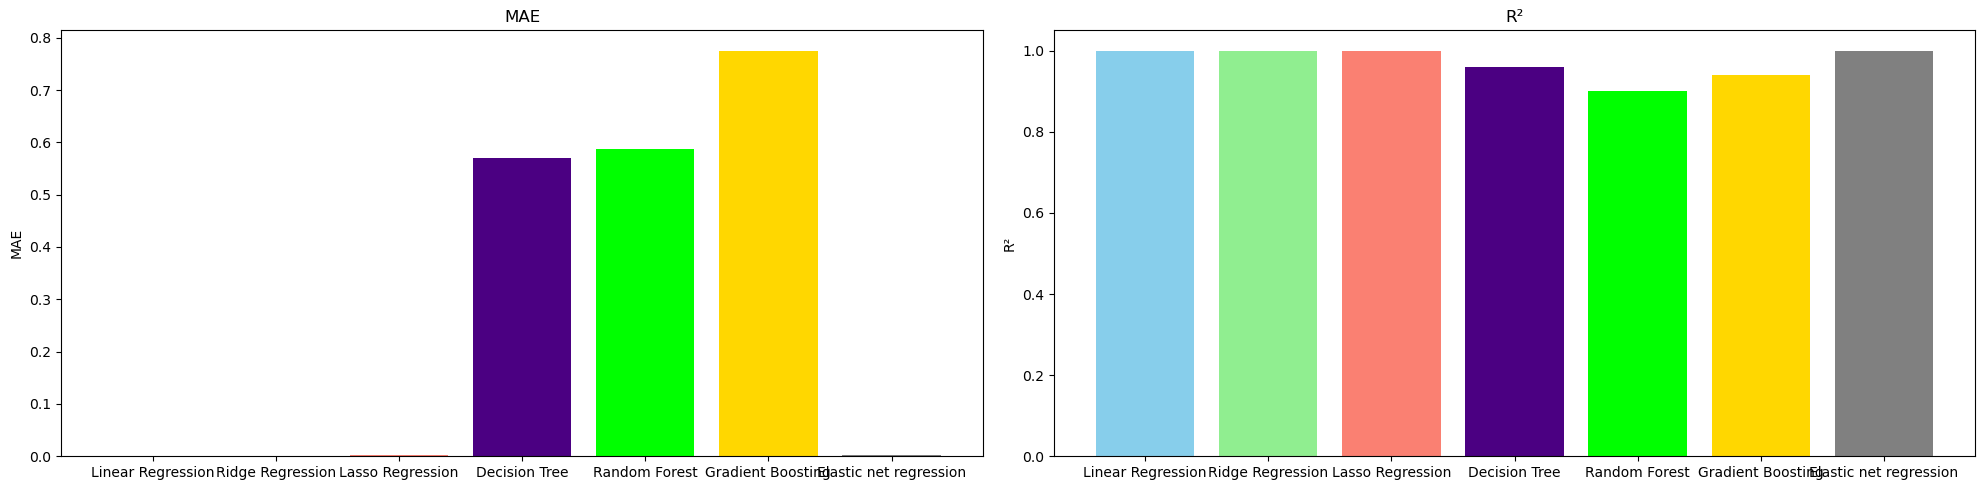

Best Model Selected: ElasticNet()

Predictions on Test Data:
   Actual  Predicted
0       2   2.000497
1       0   0.000621
2       0   0.000198
3       3   3.000628
4       1   1.000632


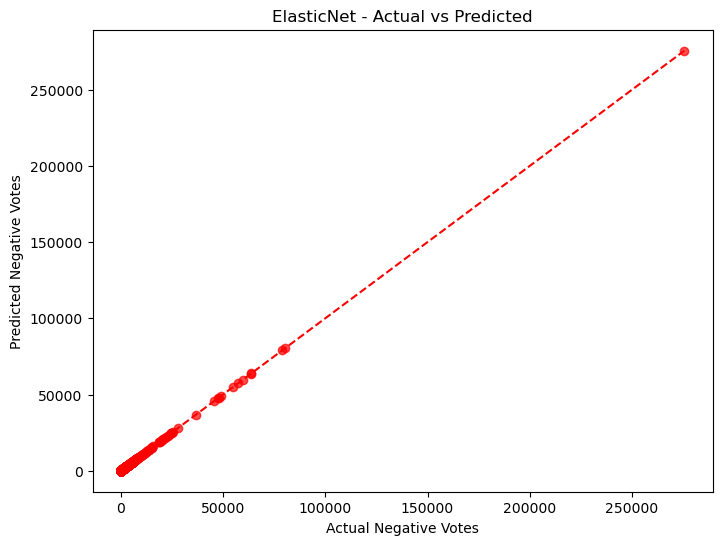

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder,MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso , ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#step 1 : Import and preprocessing data

tnd = pd.read_csv("F:\\skill\\programming\\ON ACADEMY\\projects\\Final ML\\ML\\train.csv")
ttd = pd.read_csv("F:\\skill\\programming\\ON ACADEMY\\projects\\Final ML\\ML\\test.csv")

tnd['is_ads_enabled'] = tnd['is_ads_enabled'].map({True: 1, False: 0})
tnd['has_subtitles'] = tnd['has_subtitles'].map({True: 1, False: 0})
tnd['is_comments_enabled'] = tnd['is_comments_enabled'].map({True: 1, False: 0})
tnd['is_age_limit'] = tnd['is_age_limit'].map({True: 1, False: 0})
tnd['is_live_content'] = tnd['is_live_content'].map({True: 1, False: 0})

ttd['is_ads_enabled'] = ttd['is_ads_enabled'].map({True: 1, False: 0})
ttd['has_subtitles'] = ttd['has_subtitles'].map({True: 1, False: 0})
ttd['is_comments_enabled'] = ttd['is_comments_enabled'].map({True: 1, False: 0})
ttd['is_age_limit'] = ttd['is_age_limit'].map({True: 1, False: 0})
ttd['is_live_content'] = ttd['is_live_content'].map({True: 1, False: 0})


print("First 5 rows of the train dataset:")
print(tnd.head())
print("\nSummary of the train dataset:")
print(tnd.describe())
print("\nInfo about the train dataset:")
print(tnd.info())

print("First 5 rows of the test dataset:")
print(ttd.head())
print("\nSummary of the test dataset:")
print(ttd.describe())
print("\nInfo about the test dataset:")
print(ttd.info())

mtnd=tnd.iloc[:,:]
mttd=ttd.iloc[:,:]

numeric_features = tnd.select_dtypes(include=['float64', 'int64']).columns
categorical_features = tnd.select_dtypes(include=['object']).columns
numeric_transformer = SimpleImputer(strategy='median')
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

#step3 regression models

X_train = mtnd.iloc [:, 1:9]
y_train = mtnd['dislike_count']

X_test = mttd.iloc [:, 1:9]
y_test = mttd['dislike_count']


models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Elastic net regression' : ElasticNet()
}

best_model = None
best_mae = -float('inf')

results={}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {
        "Model" : model_name ,
        'MAE': mae,
        'R²': r2
    }
    print(f"{model_name}:")
    print(f"  MAE: {mae:.3f}")
    print(f"  R²: {r2:.3f}\n")

if r2 > best_mae:
        best_mae = mae
        best_model = model

print(f"{model_name} Performance:")
print(f"  MAE: {mae:.3f}")
print(f"  R²: {r2:.3f}\n")

results_df = pd.DataFrame(results).T

print(results_df.sort_values(by='MAE'))

#step 4 compare models

metrics = ["MAE", "R²"]
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(results_df["Model"], results_df[metric], color=['skyblue', 'lightgreen', 'salmon', 'indigo', 'lime', 'gold', 'gray'])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

#step 5 chosse best model

print(f"Best Model Selected: {best_model}")
y_test_pred = best_model.predict(X_test)

test_results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred})
print("\nPredictions on Test Data:")
print(test_results_df.head())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7, color="red")
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], 'r--')
plt.xlabel("Actual Negative Votes")
plt.ylabel("Predicted Negative Votes")
plt.title(f"{type(best_model).__name__} - Actual vs Predicted")
plt.show()





